# Discrete metrics — paper figure

Panel A shows absolute metabolic rate with paired ideal and real participant values. The remaining panels show paired ideal − real differences. Outlying point markers are hidden beyond 1.5 × IQR, while every observation remains included in all boxplot calculations.

In [137]:
# Configuration
RESULT_SUBFOLDER = "ideal_0814_e300_grf5e3_middleStiff_real_0814_e300_grf5e3_middleStiff"  # "grf3_angles1"
SPEEDS = [1.0, 1.2, 1.4, 1.6, 1.8]
EXCLUDE_OBJECTIVE_OUTLIERS = True
EXCLUDE_PARTICIPANT_SPEEDS = [("P5", 1.2), ("P7", 1.4), ("P8", 1.6)]
EXPORT_FIGURE = True

In [138]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, PathPatch

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "result_HC").is_dir() else cwd.parent
if not (ROOT / "result_HC").is_dir():
    raise FileNotFoundError("Could not find the repository's result directory.")

safe_name = re.sub(r"[^A-Za-z0-9]+", "_", RESULT_SUBFOLDER).strip("_")
trajectory_path = ROOT / "result_HC" / f"simulation_results_101_points_{safe_name}.csv"
outlier_path = ROOT / "result_HC" / f"objective_outliers_{safe_name}.csv"

outlier_trials = pd.DataFrame(columns=["participant", "speed"])
if EXCLUDE_OBJECTIVE_OUTLIERS:
    outlier_rows = pd.read_csv(outlier_path)
    exclusion_column = (
        "exclude_pair" if "exclude_pair" in outlier_rows.columns
        else "objective_outlier"
    )
    if exclusion_column in outlier_rows.columns:
        is_outlier = (
            outlier_rows[exclusion_column].eq(True)
            | outlier_rows[exclusion_column].astype(str).str.lower().eq("true")
        )
        outlier_rows = outlier_rows.loc[is_outlier]
    outlier_trials = outlier_rows[["participant", "speed"]].drop_duplicates()

manual_exclusions = pd.DataFrame(
    EXCLUDE_PARTICIPANT_SPEEDS, columns=["participant", "speed"]
)
outlier_trials = (
    pd.concat([outlier_trials, manual_exclusions], ignore_index=True)
    .drop_duplicates()
)

df = pd.read_csv(trajectory_path)
excluded_index = pd.MultiIndex.from_frame(outlier_trials)
trial_index = pd.MultiIndex.from_frame(df[["participant", "speed"]])
df = df.loc[~trial_index.isin(excluded_index)].copy()

# Use one common cohort for absolute boxplots and paired differences:
# retain only participant-speed cases containing both treadmill models.
models_by_trial = (
    df[["participant", "speed", "treadmill_model"]]
    .drop_duplicates()
    .groupby(["participant", "speed"])["treadmill_model"]
    .agg(frozenset)
)
complete_pair_index = pd.MultiIndex.from_tuples(
    [trial for trial, models_present in models_by_trial.items()
     if {"ideal", "real"}.issubset(models_present)],
    names=["participant", "speed"],
)
incomplete_trials = models_by_trial.loc[
    ~models_by_trial.index.isin(complete_pair_index)
]
trial_index = pd.MultiIndex.from_frame(df[["participant", "speed"]])
df = df.loc[trial_index.isin(complete_pair_index)].copy()
print(
    f"Excluded {len(incomplete_trials)} additional participant-speed trials "
    "without both ideal and real results."
)
df = df.set_index(["participant", "speed", "treadmill_model", "node"]).sort_index()

def peak_moment(trajectory):
    return trajectory.max()

def peak_hip_extension_moment(trajectory):
    # Hip flexion is positive in the model convention; report the negative extension peak as a magnitude.
    return -trajectory.min()

def rom(trajectory):
    return trajectory.max() - trajectory.min()

metric_rows = []
for (participant, speed, model), trial in df.groupby(
    level=["participant", "speed", "treadmill_model"]
):
    metric_rows.append({
        "participant": participant,
        "speed": speed,
        "treadmill_model": model,
        "metabolic_rate_w_per_kg": trial["metabolic_rate_w_per_kg"].iloc[0],
        "hip_peak_moment": peak_hip_extension_moment(trial["M_hip_r_nm_per_kg"]),
        "knee_peak_moment": peak_moment(trial["M_knee_r_nm_per_kg"]),
        "ankle_peak_moment": peak_moment(trial["M_ankle_r_nm_per_kg"]),
        "hip_rom": rom(trial["q_hip_r_deg"]),
        "ankle_rom": rom(trial["q_ankle_r_deg"]),
        "cadence_steps_per_min": trial["cadence_steps_per_min"].iloc[0],
    })

metrics_df = pd.DataFrame(metric_rows).sort_values(
    ["participant", "speed", "treadmill_model"]
).reset_index(drop=True)
print(f"Participant-speed trials excluded from both models: {len(outlier_trials)}")
print(f"Trials retained: {len(metrics_df)}")

Excluded 0 additional participant-speed trials without both ideal and real results.
Participant-speed trials excluded from both models: 7
Trials retained: 136


In [139]:
# Pair ideal and real values within participant and walking speed.
metric_columns = [
    "metabolic_rate_w_per_kg", "cadence_steps_per_min",
    "hip_peak_moment", "knee_peak_moment", "ankle_peak_moment",
    "hip_rom", "ankle_rom",
]
long_metrics = metrics_df.melt(
    id_vars=["participant", "speed", "treadmill_model"],
    value_vars=metric_columns, var_name="metric", value_name="value",
)
paired_df = long_metrics.pivot_table(
    index=["participant", "speed", "metric"],
    columns="treadmill_model", values="value", aggfunc="first",
).dropna(subset=["ideal", "real"]).reset_index()
paired_df["difference"] = paired_df["ideal"] - paired_df["real"]
moment_metrics = ["hip_peak_moment", "knee_peak_moment", "ankle_peak_moment"]
moment_rows = paired_df["metric"].isin(moment_metrics)
paired_df.loc[moment_rows, "difference"] = (
    paired_df.loc[moment_rows, "ideal"].abs()
    - paired_df.loc[moment_rows, "real"].abs()
)
# All paired differences retain their original units.

def within_whiskers(data, value_column, group_columns):
    grouped = data.groupby(group_columns)[value_column]
    q1 = grouped.transform(lambda values: values.quantile(0.25))
    q3 = grouped.transform(lambda values: values.quantile(0.75))
    iqr = q3 - q1
    return data[data[value_column].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)]

def add_pooled_difference_box(ax, plot_data, metric, position=-0.55):
    """Add a gray all-speeds box; all values remain in its statistics."""
    values = plot_data["difference"].dropna().to_numpy()
    ax.boxplot(
        values, positions=[position], vert=False, widths=0.3,
        patch_artist=True, showfliers=False, manage_ticks=False,
        medianprops={"color": "white", "linewidth": 1.5},
        whiskerprops={"color": "0.25", "linewidth": 1},
        capprops={"color": "0.25", "linewidth": 1},
        boxprops={"facecolor": "0.55", "edgecolor": "0.25", "alpha": 0.9},
    )
    ax.scatter(values.mean(), position, marker="o", s=MEAN_DOT_SIZE, facecolor="0.1",
               edgecolor="white", linewidth=0.4, zorder=6)
    direction = literature_direction[metric]
    if direction != 0:
        arrow_scale = 2.0 if metric == "ankle_peak_moment" else 1.0
        arrow_length = max(
            arrow_scale * LITERATURE_ARROW_FRACTION * np.ptp(values),
            np.finfo(float).eps,
        )
        arrow_start = 0.0
        arrow_end = arrow_start + direction * arrow_length
        ax.annotate("", xy=(arrow_end, position - 0.20),
                    xytext=(arrow_start, position - 0.20),
                    arrowprops=LITERATURE_ARROW_PROPS, annotation_clip=False, zorder=8)
        ax.update_datalim(np.array([[arrow_end, position - 0.20]]))
        ax.autoscale_view(scalex=True, scaley=False)
    return position

model_order = ["ideal", "real"]
model_palette = {"ideal": "0.35", "real": "0.72"}
speed_palette = dict(zip(SPEEDS, sns.color_palette("rocket_r", len(SPEEDS))))
SPEED_LABELS = [f"{speed:.1f}" for speed in SPEEDS]
metrics_df["speed_label"] = pd.Categorical(
    metrics_df["speed"].map(lambda speed: f"{speed:.1f}"),
    categories=SPEED_LABELS, ordered=True,
)
paired_df["speed_label"] = pd.Categorical(
    paired_df["speed"].map(lambda speed: f"{speed:.1f}"),
    categories=SPEED_LABELS, ordered=True,
)
speed_positions = np.arange(len(SPEEDS)) * 0.68
LITERATURE_ARROW_FRACTION = 0.20
LITERATURE_ARROW_PROPS = {
    "arrowstyle": "-|>", "color": "0.05", "lw": 2.2, "mutation_scale": 16
}
# Literature directions: +1 = increasing/right, -1 = decreasing/left,
# and 0 = no significant difference (no arrow). Differences are ideal - real.
literature_direction = {
    "metabolic_rate_w_per_kg": 1,
    "cadence_steps_per_min": -1,
    "hip_peak_moment": -1,
    "knee_peak_moment": 1,
    "ankle_peak_moment": 1,
    "hip_rom": 0,
    "ankle_rom": 0,
}

def add_pooled_metabolic_boxes(ax, metabolic_data, position):
    """Pool speeds separately for ideal and real without mixing the models."""
    pooled_colors = {"ideal": "0.40", "real": "0.70"}
    pooled_offsets = {"ideal": -0.15, "real": 0.15}
    for model in model_order:
        values = metabolic_data.loc[
            metabolic_data["treadmill_model"] == model, "metabolic_rate_w_per_kg"
        ].dropna().to_numpy()
        model_position = position + pooled_offsets[model]
        ax.boxplot(
            values, positions=[model_position], vert=True, widths=0.24,
            patch_artist=True, showfliers=False, manage_ticks=False,
            medianprops={"color": "white", "linewidth": 1.5},
            whiskerprops={"color": "0.25", "linewidth": 1},
            capprops={"color": "0.25", "linewidth": 1},
            boxprops={"facecolor": pooled_colors[model], "edgecolor": "0.25", "alpha": 0.9},
        )
        ax.scatter(model_position, values.mean(), marker="o", s=MEAN_DOT_SIZE,
                   facecolor="0.1", edgecolor="white", linewidth=0.4, zorder=6)
    all_values = metabolic_data["metabolic_rate_w_per_kg"].dropna().to_numpy()
    arrow_length = max(LITERATURE_ARROW_FRACTION * np.ptp(all_values), np.finfo(float).eps)
    arrow_start = np.median(all_values)
    direction = literature_direction["metabolic_rate_w_per_kg"]
    ax.annotate("", xy=(position + 0.36, arrow_start + direction * arrow_length),
                xytext=(position + 0.36, arrow_start),
                arrowprops=LITERATURE_ARROW_PROPS, annotation_clip=False, zorder=8)
    ax.set_xticks(range(len(SPEEDS) + 1), SPEED_LABELS + ["All"])

def color_metabolic_box_outlines_by_speed(ax):
    """Keep model fills gray and map only speed-specific box edges to speed colors."""
    for box in [patch for patch in ax.patches if isinstance(patch, PathPatch)]:
        x_vertices = box.get_path().vertices[:, 0]
        speed_index = int(round((x_vertices.min() + x_vertices.max()) / 2))
        if 0 <= speed_index < len(SPEEDS):
            box.set_edgecolor(speed_palette[SPEEDS[speed_index]])
            box.set_linewidth(1.8)

/tmp/ipykernel_1511314/1882998652.py:98: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_1511314/1882998652.py:98: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_1511314/2542352714.py:37: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_1511314/2542352714.py:37: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_1511314/2542352714.py:37: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use ori

Saved result_HC/discrete_metrics_paper_plot_stacked_ideal_0814_e300_grf5e3_middleStiff_real_0814_e300_grf5e3_middleStiff.pdf


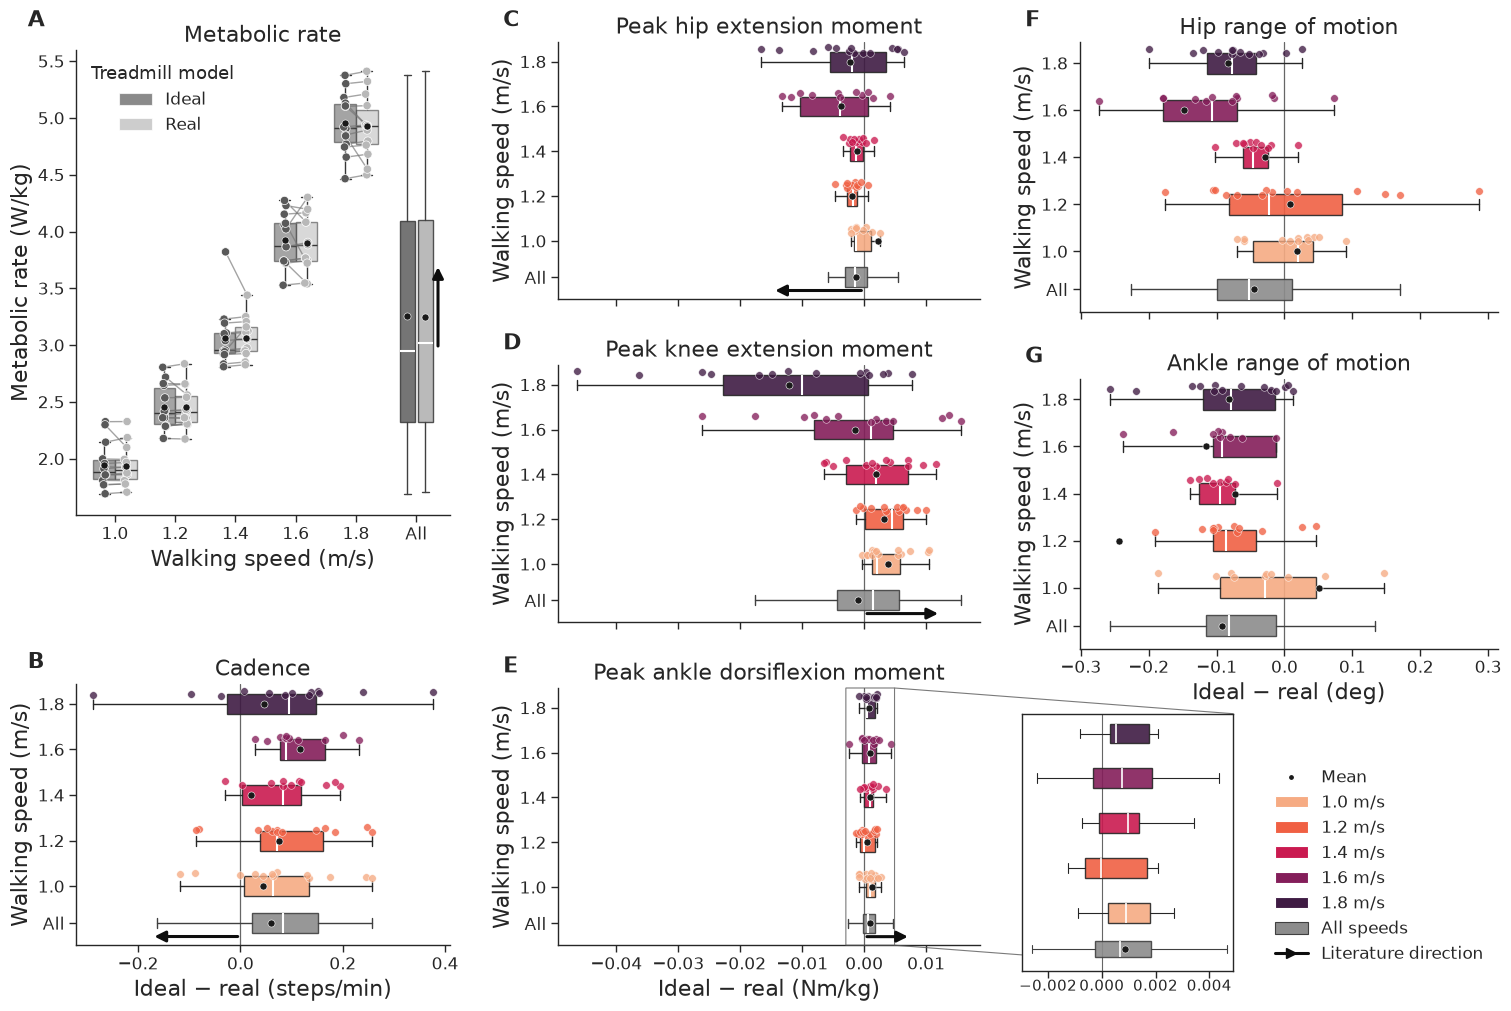

In [140]:
# Alternative paper layout: related metrics stacked with shared x-axes.
sns.set_theme(style="ticks", context="paper", font_scale=1.35)
# Centralized figure styling. Increase these values for larger markers/text.
PARTICIPANT_DOT_SIZE = 30
MEAN_DOT_SIZE = 26
METABOLIC_DOT_SIZE = 36
SUBPLOT_TITLE_FONTSIZE = plt.rcParams["axes.titlesize"]*1.2
AXIS_LABEL_FONTSIZE = plt.rcParams["axes.labelsize"]*1.2
metabolic = metrics_df[[
    "participant", "speed", "speed_label",
    "treadmill_model", "metabolic_rate_w_per_kg",
]].dropna()
metabolic_pairs = paired_df[paired_df["metric"] == "metabolic_rate_w_per_kg"]
offsets = {"ideal": -0.18, "real": 0.18}
point_offsets = offsets.copy()
rng = np.random.default_rng(42)
model_handles = [
    Patch(facecolor=model_palette[model], alpha=0.65, label=model.title())
    for model in model_order
] + [Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="0.1",
            markeredgecolor="white", markersize=4.5, label="Mean")]
speed_handles = [
    Patch(facecolor=speed_palette[speed], label=f"{speed:.1f} m/s")
    for speed in SPEEDS
] + [
    Patch(facecolor="0.55", edgecolor="0.25", label="All speeds"),
    Line2D([0], [0], color="0.05", linewidth=2.2, marker=">", markersize=7,
           label="Literature direction"),
]

def draw_compact_difference_box(ax, metric, title):
    plot_data = paired_df[paired_df["metric"] == metric]
    for speed_index, speed in enumerate(SPEEDS):
        position = speed_positions[speed_index]
        values = plot_data.loc[plot_data["speed"] == speed, "difference"].dropna().to_numpy()
        color = speed_palette[speed]
        ax.boxplot(
            values, positions=[position], vert=False, widths=0.3,
            patch_artist=True, showfliers=False, manage_ticks=False,
            medianprops={"color": "white", "linewidth": 1.5},
            whiskerprops={"color": "0.15", "linewidth": 1},
            capprops={"color": "0.15", "linewidth": 1},
            boxprops={"facecolor": color, "edgecolor": "0.15", "alpha": 0.9},
        )
        q1, q3 = np.quantile(values, [0.25, 0.75])
        iqr = q3 - q1
        visible_values = values[(values >= q1 - 1.5 * iqr) & (values <= q3 + 1.5 * iqr)]
        point_y = position + rng.uniform(0.12, 0.22, len(visible_values))
        ax.scatter(
            visible_values, point_y, color=color, s=PARTICIPANT_DOT_SIZE, alpha=0.78,
            edgecolor="white", linewidth=0.4, zorder=4,
        )
        ax.scatter(
            values.mean(), position, marker="o", s=MEAN_DOT_SIZE,
            facecolor="0.1", edgecolor="white", linewidth=0.4, zorder=6,
        )
    pooled_position = add_pooled_difference_box(ax, plot_data, metric)
    ax.axvline(0, color="0.4", linewidth=0.9, zorder=0)
    ax.set_yticks([pooled_position, *speed_positions], ["All", *SPEED_LABELS])
    ax.set_ylim(-0.88, speed_positions[-1] + 0.30)
    ax.set_title(title)
    ax.set_ylabel("Walking speed (m/s)")

fig_stacked = plt.figure(figsize=(15, 10), constrained_layout=True)
outer = fig_stacked.add_gridspec(
    1, 5, width_ratios=[0.92, 0.05, 1, 0.05, 1],
)
left_grid = outer[0].subgridspec(
    2, 1, height_ratios=[1.28, 0.72], hspace=0.16,
)
moment_grid = outer[2].subgridspec(3, 1, hspace=0.08)
rom_grid = outer[4].subgridspec(3, 1, hspace=0.08)

ax_metabolic = fig_stacked.add_subplot(left_grid[0])
sns.boxplot(
    data=metabolic, x="speed_label", y="metabolic_rate_w_per_kg",
    hue="treadmill_model", order=SPEED_LABELS, hue_order=model_order,
    palette=model_palette, width=0.72, showfliers=False,
    boxprops={"alpha": 0.55}, ax=ax_metabolic,
)
for speed_position, speed in enumerate(SPEEDS):
    speed_pairs = metabolic_pairs[metabolic_pairs["speed"] == speed]
    jitters = rng.uniform(-0.03, 0.03, len(speed_pairs))
    for jitter, (_, pair) in zip(jitters, speed_pairs.iterrows()):
        xs = [speed_position + point_offsets["ideal"] + jitter, speed_position + point_offsets["real"] + jitter]
        ys = [pair["ideal"], pair["real"]]
        ax_metabolic.plot(xs, ys, color="0.45", linewidth=1.0, alpha=0.65, zorder=3)
        ax_metabolic.scatter(
            xs, ys, color=[model_palette["ideal"], model_palette["real"]],
            s=METABOLIC_DOT_SIZE, edgecolor="white", linewidth=0.5, zorder=4,
        )
    for model in model_order:
        model_mean = speed_pairs[model].mean()
        ax_metabolic.scatter(
            speed_position + offsets[model], model_mean, marker="o",
            s=MEAN_DOT_SIZE, facecolor="0.1", edgecolor="white", linewidth=0.4, zorder=6,
        )
add_pooled_metabolic_boxes(ax_metabolic, metabolic, len(SPEEDS))
ax_metabolic.set(title="Metabolic rate", xlabel="Walking speed (m/s)", ylabel="Metabolic rate (W/kg)")
if ax_metabolic.get_legend() is not None:
    ax_metabolic.get_legend().remove()
ax_metabolic.legend(
    handles=[Patch(facecolor=model_palette[model], alpha=0.7, label=model.title())
             for model in model_order],
    title="Treadmill model", loc="best", frameon=False,
)

ax_cadence = fig_stacked.add_subplot(left_grid[1])
draw_compact_difference_box(ax_cadence, "cadence_steps_per_min", "Cadence")
ax_cadence.set_xlabel("Ideal − real (steps/min)")

moment_axes = []
for index in range(3):
    moment_axes.append(fig_stacked.add_subplot(
        moment_grid[index], sharex=moment_axes[0] if moment_axes else None,
    ))
moment_specs = [
    ("hip_peak_moment", "Peak hip extension moment"),
    ("knee_peak_moment", "Peak knee extension moment"),
    ("ankle_peak_moment", "Peak ankle dorsiflexion moment"),
]
for index, (ax, (metric, title)) in enumerate(zip(moment_axes, moment_specs)):
    draw_compact_difference_box(ax, metric, title)
    if index < len(moment_axes) - 1:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Ideal − real (Nm/kg)")

# Inset: magnify the central ankle-moment range without changing the main axis.
ankle_inset = moment_axes[-1].inset_axes([1.1, -0.1, 0.5, 1])
ankle_inset.set_in_layout(False)
ankle_data = paired_df[paired_df["metric"] == "ankle_peak_moment"]
ankle_central_values = []
for speed_index, speed in enumerate(SPEEDS):
    position = speed_positions[speed_index]
    values = ankle_data.loc[ankle_data["speed"] == speed, "difference"].dropna().to_numpy()
    q1, q3 = np.quantile(values, [0.25, 0.75])
    iqr = q3 - q1
    central_values = values[(values >= q1 - 1.5 * iqr) & (values <= q3 + 1.5 * iqr)]
    ankle_central_values.extend(central_values)
    ankle_inset.boxplot(
        values, positions=[position], vert=False, widths=0.3,
        patch_artist=True, showfliers=False, manage_ticks=False,
        medianprops={"color": "white", "linewidth": 1.2},
        whiskerprops={"color": "0.15", "linewidth": 0.8},
        capprops={"color": "0.15", "linewidth": 0.8},
        boxprops={"facecolor": speed_palette[speed], "edgecolor": "0.15", "alpha": 0.9},
    )
ankle_pooled_values = ankle_data["difference"].dropna().to_numpy()
ankle_pooled_position = -0.55
ankle_inset.boxplot(
    ankle_pooled_values, positions=[ankle_pooled_position], vert=False, widths=0.25,
    patch_artist=True, showfliers=False, manage_ticks=False,
    medianprops={"color": "white", "linewidth": 1.2},
    whiskerprops={"color": "0.25", "linewidth": 0.8},
    capprops={"color": "0.25", "linewidth": 0.8},
    boxprops={"facecolor": "0.55", "edgecolor": "0.25", "alpha": 0.9},
)
ankle_inset.scatter(
    ankle_pooled_values.mean(), ankle_pooled_position, marker="o", s=MEAN_DOT_SIZE,
    facecolor="0.1", edgecolor="white", linewidth=0.35, zorder=6,
)
central_min, central_max = np.min(ankle_central_values), np.max(ankle_central_values)
central_padding = 0.08 * (central_max - central_min)
ankle_inset.set_xlim(central_min - central_padding, central_max + central_padding)
ankle_inset.set_ylim(-0.88, speed_positions[-1] + 0.30)
ankle_inset.set_yticks([])
ankle_inset.axvline(0, color="0.4", linewidth=0.8, zorder=0)
ankle_inset.tick_params(axis="x", labelsize=11, pad=1)
ankle_indicator = moment_axes[-1].indicate_inset_zoom(
    ankle_inset, edgecolor="0.35", alpha=0.8,
)
ankle_indicator.set_in_layout(False)

rom_axes = []
for index in range(2):
    rom_axes.append(fig_stacked.add_subplot(
        rom_grid[index], sharex=rom_axes[0] if rom_axes else None,
    ))
ax_rom_legend = fig_stacked.add_subplot(rom_grid[2])
ax_rom_legend.axis("off")
rom_specs = [("hip_rom", "Hip range of motion"), ("ankle_rom", "Ankle range of motion")]
for index, (ax, (metric, title)) in enumerate(zip(rom_axes, rom_specs)):
    draw_compact_difference_box(ax, metric, title)
    if index == 0:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel("Ideal − real (deg)")

all_axes = [ax_metabolic, ax_cadence, *moment_axes, *rom_axes]
for panel, ax in zip(list("ABCDEFG"), all_axes):
    ax.title.set_fontsize(SUBPLOT_TITLE_FONTSIZE)
    ax.xaxis.label.set_size(AXIS_LABEL_FONTSIZE)
    ax.yaxis.label.set_size(AXIS_LABEL_FONTSIZE)
    ax.text(-0.13, 1.04, panel, transform=ax.transAxes, fontsize=16, fontweight="bold", va="bottom")
sns.despine(fig=fig_stacked)
ax_rom_legend.legend(
    handles=model_handles[2:] + speed_handles, loc="right",
    ncol=1, frameon=False,
)
if EXPORT_FIGURE:
    output_path = ROOT / "result_HC" / f"discrete_metrics_paper_plot_stacked_{safe_name}.pdf"
    fig_stacked.savefig(output_path, bbox_inches="tight")
    print(f"Saved {output_path.relative_to(ROOT)}")
plt.show()

## Paired metric differences across all speeds

Count, mean, and median of the paired **ideal − real** difference for each discrete metric.

In [141]:
metric_summary_per_speed = (
    paired_df
    .groupby(["metric"])["difference"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

for metric in metric_columns:
    print(f"\n{metric}")

    display(
        metric_summary_per_speed
        .query("metric == @metric")
        .drop(columns="metric")
        .reset_index(drop=True)
    )


metabolic_rate_w_per_kg


,count,mean,median
0,68,0.011839,-0.014227



cadence_steps_per_min


,count,mean,median
0,68,0.060341,0.083478



hip_peak_moment


...

,count,mean,median
0,68,0.000865,0.00068



hip_rom


,count,mean,median
0,68,-0.045438,-0.051695



ankle_rom


,count,mean,median
0,68,-0.092238,-0.08185


## Paired metric differences by speed

In [142]:
metric_summary_per_speed = (
    paired_df
    .groupby(["metric", "speed"])["difference"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

for metric in metric_columns:
    print(f"\n{metric}")

    display(
        metric_summary_per_speed
        .query("metric == @metric")
        .drop(columns="metric")
        .reset_index(drop=True)
    )


metabolic_rate_w_per_kg


,speed,count,mean,median
0,1.0,14,0.006910,-0.004447
1,1.2,14,0.002435,-0.007519
2,1.4,13,-0.001066,-0.016923
3,1.6,13,0.023290,-0.019255
4,1.8,14,0.027519,-0.022061



cadence_steps_per_min


,speed,count,mean,median
0,1.0,14,0.044724,0.062636
1,1.2,14,0.074503,0.071300
2,1.4,13,0.020823,0.083991
3,1.6,13,0.115893,0.089592
4,1.8,14,0.046908,0.094381



hip_peak_moment


...

,speed,count,mean,median
0,1.0,14,0.001327,0.000897
1,1.2,14,0.000408,-0.000016
2,1.4,13,0.000873,0.000991
3,1.6,13,0.000863,0.000744
4,1.8,14,0.000854,0.000528



hip_rom


,speed,count,mean,median
0,1.0,14,0.019053,0.020040
1,1.2,14,0.008274,-0.022555
2,1.4,13,-0.028510,-0.045811
3,1.6,13,-0.148757,-0.106657
4,1.8,14,-0.083419,-0.076660



ankle_rom


,speed,count,mean,median
0,1.0,14,0.051259,-0.028490
1,1.2,14,-0.243235,-0.085615
2,1.4,13,-0.072402,-0.095085
3,1.6,13,-0.115341,-0.091568
4,1.8,14,-0.081705,-0.078560


## Absolute metabolic rate by speed and treadmill model

In [143]:
metabolic_summary = (
    metrics_df
    .groupby(["speed", "treadmill_model"])[
        "metabolic_rate_w_per_kg"
    ]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(metabolic_summary)

,speed,treadmill_model,count,mean,median
0,1.0,ideal,14,1.941316,1.884733
1,1.0,real,14,1.934406,1.898618
2,1.2,ideal,14,2.453471,2.400811
3,1.2,real,14,2.451035,2.411333
4,1.4,ideal,13,3.062948,2.956158
5,1.4,real,13,3.064014,3.054994
6,1.6,ideal,13,3.923318,3.869414
7,1.6,real,13,3.900028,3.883083
8,1.8,ideal,14,4.953175,4.913017
9,1.8,real,14,4.925655,4.929437


## Absolute metabolic rate across all speeds

In [144]:
metabolic_summary = (
    metrics_df
    .groupby(["treadmill_model"])[
        "metabolic_rate_w_per_kg"
    ]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(metabolic_summary)

,treadmill_model,count,mean,median
0,ideal,68,3.260190,2.951332
1,real,68,3.248352,3.014492


## Largest individual ankle dorsiflexion-moment difference

Participant-speed pair with the largest absolute paired difference for the ankle dorsiflexion-moment peak.

In [145]:
ankle_peak_moment_differences = paired_df[
    paired_df["metric"] == "ankle_peak_moment"
]

display(
    ankle_peak_moment_differences.loc[
        [ankle_peak_moment_differences["difference"].abs().idxmax()]
    ]
)

treadmill_model,participant,speed,metric,ideal,real,difference,speed_label
294,P4,1.2,ankle_peak_moment,0.149222,0.139181,0.010041,1.2


In [146]:
ankle_peak_moment_differences = paired_df[
    paired_df["metric"] == "ankle_peak_moment"
]

display(
    ankle_peak_moment_differences.loc[
        [ankle_peak_moment_differences["difference"].abs().idxmax()]
    ]
)

treadmill_model,participant,speed,metric,ideal,real,difference,speed_label
294,P4,1.2,ankle_peak_moment,0.149222,0.139181,0.010041,1.2


## Participant-level metabolic-rate percentage changes

Percentage change is calculated as `(real − ideal) / ideal × 100`. Positive values mean metabolic rate is higher in the real-treadmill model; negative values mean it is higher in the ideal-treadmill model. The table contains only participant-speed pairs retained by the notebook's exclusion rules.

In [147]:
metabolic_percent_change_table = (
    paired_df.loc[
        paired_df["metric"] == "metabolic_rate_w_per_kg",
        ["participant", "speed", "ideal", "real", "difference"],
    ]
    .copy()
)
metabolic_percent_change_table["percent_change_real_vs_ideal"] = (
    (metabolic_percent_change_table["real"]
     - metabolic_percent_change_table["ideal"])
    / metabolic_percent_change_table["ideal"]
    * 100
)
metabolic_percent_change_table["higher_model"] = np.select(
    [
        metabolic_percent_change_table["real"]
        > metabolic_percent_change_table["ideal"],
        metabolic_percent_change_table["ideal"]
        > metabolic_percent_change_table["real"],
    ],
    ["Real", "Ideal"],
    default="Equal",
)
metabolic_percent_change_table["participant_number"] = (
    metabolic_percent_change_table["participant"]
    .str.extract(r"(\d+)", expand=False)
    .astype(int)
)
metabolic_percent_change_table = (
    metabolic_percent_change_table
    .sort_values(["participant_number", "speed"])
    .drop(columns="participant_number")
    .reset_index(drop=True)
)
with pd.option_context("display.max_rows", None):
    display(metabolic_percent_change_table)

treadmill_model,participant,speed,ideal,real,difference,percent_change_real_vs_ideal,higher_model
0,P1,1.0,1.858945,1.859318,-0.000373,0.020090,Real
1,P1,1.2,2.384316,2.398392,-0.014077,0.590382,Real
2,P1,1.4,2.946506,2.960884,-0.014378,0.487973,Real
3,P1,1.6,3.869414,3.883083,-0.013670,0.353271,Real
4,P1,1.8,4.905730,4.929603,-0.023873,0.486638,Real
5,P2,1.0,2.298551,2.098577,0.199975,-8.700028,Ideal
6,P2,1.2,2.645271,2.655183,-0.009912,0.374697,Real
7,P2,1.4,3.193446,3.206457,-0.013011,0.407442,Real
8,P2,1.6,4.060829,4.082239,-0.021409,0.527212,Real
9,P2,1.8,5.301302,5.321550,-0.020248,0.381951,Real


## Largest ideal–real differences

This section reports extrema for the discrete metrics, individual node-by-node trajectories, and the mean/median difference trajectories. Signed differences remain **ideal − real**; the absolute-difference columns are used only to locate the largest discrepancy.

In [148]:
# Individual participant-speed extrema for every discrete metric
individual_metric_difference_summary = (
    paired_df.groupby("metric")["difference"]
    .agg(count="count", mean="mean", median="median",
         minimum="min", maximum="max")
)
largest_individual_indices = (
    paired_df.assign(abs_difference=paired_df["difference"].abs())
    .groupby("metric")["abs_difference"]
    .idxmax()
)
largest_individual_rows = (
    paired_df.loc[largest_individual_indices,
                  ["metric", "participant", "speed",
                   "ideal", "real", "difference"]]
    .set_index("metric")
    .rename(columns={
        "participant": "participant_at_largest_absolute",
        "speed": "speed_at_largest_absolute",
        "ideal": "ideal_at_largest_absolute",
        "real": "real_at_largest_absolute",
        "difference": "largest_absolute_difference_signed",
    })
)
individual_metric_difference_summary = (
    individual_metric_difference_summary
    .join(largest_individual_rows)
    .reset_index()
)
display(individual_metric_difference_summary)

# Full-trajectory ideal-minus-real extrema
#
# Unlike the discrete peak/ROM metrics above, this table starts from every
# paired gait-cycle node. It reports the extrema of the mean and median
# difference trajectories, both per speed and pooled across all speeds.
trajectory_columns = [
    "q_hip_r_deg", "q_knee_r_deg", "q_ankle_r_deg",
    "M_hip_r_nm_per_kg", "M_knee_r_nm_per_kg",
    "M_ankle_r_nm_per_kg",
]

trajectory_wide = df[trajectory_columns].unstack("treadmill_model")
trajectory_differences = (
    trajectory_wide.xs("ideal", level="treadmill_model", axis=1)
    - trajectory_wide.xs("real", level="treadmill_model", axis=1)
).dropna()

ideal_trajectories = trajectory_wide.xs(
    "ideal", level="treadmill_model", axis=1
).loc[trajectory_differences.index]
real_trajectories = trajectory_wide.xs(
    "real", level="treadmill_model", axis=1
).loc[trajectory_differences.index]
direction_labels = {
    "q_hip_r_deg": ("flexion", "extension"),
    "M_hip_r_nm_per_kg": ("flexion", "extension"),
    "q_knee_r_deg": ("extension", "flexion"),
    "M_knee_r_nm_per_kg": ("extension", "flexion"),
    "q_ankle_r_deg": ("dorsiflexion", "plantarflexion"),
    "M_ankle_r_nm_per_kg": ("dorsiflexion", "plantarflexion"),
}
individual_node_extrema_rows = []
for variable in trajectory_columns:
    ideal_values = ideal_trajectories[variable]
    differences_at_nodes = trajectory_differences[variable]
    positive_direction, negative_direction = direction_labels[variable]
    for direction, mask in (
        (positive_direction, ideal_values > 0),
        (negative_direction, ideal_values < 0),
    ):
        directional_differences = differences_at_nodes.loc[mask].dropna()
        largest_index = directional_differences.abs().idxmax()
        participant, speed, node = largest_index
        signed_difference = directional_differences.loc[largest_index]
        individual_node_extrema_rows.append({
            "variable": variable,
            "direction": direction,
            "participant": participant,
            "speed": speed,
            "node": node,
            "gait_cycle_percent": 100 * node / float(
                trajectory_differences.index.get_level_values("node").max()
            ),
            "ideal_value": ideal_trajectories.loc[largest_index, variable],
            "real_value": real_trajectories.loc[largest_index, variable],
            "ideal_minus_real": signed_difference,
            "absolute_difference": abs(signed_difference),
        })

individual_node_difference_extrema = (
    pd.DataFrame(individual_node_extrema_rows)
    .sort_values(["variable", "direction"])
    .reset_index(drop=True)
)
display(individual_node_difference_extrema)

node_max = float(trajectory_differences.index.get_level_values("node").max())
trajectory_extrema_rows = []
speed_groups = [
    *[(speed, trajectory_differences.xs(speed, level="speed", drop_level=False))
      for speed in SPEEDS],
    ("all", trajectory_differences),
]

for speed, speed_data in speed_groups:
    grouped_nodes = speed_data.groupby(level="node")
    for statistic, center_curve in (
        ("mean", grouped_nodes.mean()),
        ("median", grouped_nodes.median()),
    ):
        for variable in trajectory_columns:
            values = center_curve[variable].dropna()
            minimum_node = values.idxmin()
            maximum_node = values.idxmax()
            absolute_node = values.abs().idxmax()
            trajectory_extrema_rows.append({
                "variable": variable,
                "speed": speed,
                "statistic": statistic,
                "minimum_ideal_minus_real": values.loc[minimum_node],
                "node_at_minimum": minimum_node,
                "gait_cycle_at_minimum_percent": 100 * minimum_node / node_max,
                "maximum_ideal_minus_real": values.loc[maximum_node],
                "node_at_maximum": maximum_node,
                "gait_cycle_at_maximum_percent": 100 * maximum_node / node_max,
                "largest_absolute_difference": values.loc[absolute_node],
                "node_at_largest_absolute_difference": absolute_node,
                "gait_cycle_at_largest_absolute_difference_percent":
                    100 * absolute_node / node_max,
            })

trajectory_difference_extrema = pd.DataFrame(trajectory_extrema_rows)
trajectory_difference_extrema["speed_sort"] = (
    trajectory_difference_extrema["speed"].replace("all", np.inf).astype(float)
)
trajectory_difference_extrema = (
    trajectory_difference_extrema
    .sort_values(["variable", "speed_sort", "statistic"])
    .drop(columns="speed_sort")
    .reset_index(drop=True)
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(trajectory_difference_extrema)


,metric,count,mean,median,minimum,maximum,participant_at_largest_absolute,speed_at_largest_absolute,ideal_at_largest_absolute,real_at_largest_absolute,largest_absolute_difference_signed
0,ankle_peak_moment,68,0.000865,0.000680,-0.008740,0.010041,P4,1.2,0.149222,0.139181,0.010041
1,ankle_rom,68,-0.092238,-0.081850,-2.777601,1.558735,P13,1.2,30.339196,33.116796,-2.777601
2,cadence_steps_per_min,68,0.060341,0.083478,-0.456130,0.412392,P12,1.4,160.961671,161.417800,-0.456130
3,hip_peak_moment,68,-0.001401,-0.001472,-0.028282,0.045803,P7,1.0,0.589704,0.543902,0.045803
4,hip_rom,68,-0.045438,-0.051695,-0.765841,0.363033,P9,1.6,34.792104,35.557945,-0.765841
5,knee_peak_moment,68,-0.000963,0.001449,-0.046314,0.015620,P6,1.8,0.957306,1.003620,-0.046314
6,metabolic_rate_w_per_kg,68,0.011839,-0.014227,-0.278081,0.381284,P12,1.4,3.820759,3.439475,0.381284


,variable,direction,participant,speed,node,gait_cycle_percent,ideal_value,real_value,ideal_minus_real,absolute_difference
0,M_ankle_r_nm_per_kg,dorsiflexion,P13,1.2,65,65.0,0.039822,-0.019462,0.059285,0.059285
1,M_ankle_r_nm_per_kg,plantarflexion,P6,1.8,13,13.0,-0.615457,-0.515701,-0.099756,0.099756
2,M_hip_r_nm_per_kg,extension,P12,1.6,8,8.0,-0.251074,-0.188691,-0.062383,0.062383
3,M_hip_r_nm_per_kg,flexion,P6,1.8,88,88.0,0.114280,0.161476,-0.047196,0.047196
4,M_knee_r_nm_per_kg,extension,P6,1.8,11,11.0,0.872569,0.937208,-0.064639,0.064639
5,M_knee_r_nm_per_kg,flexion,P6,1.8,93,93.0,-0.591635,-0.622388,0.030753,0.030753
6,q_ankle_r_deg,dorsiflexion,P13,1.2,1,1.0,2.436507,4.259195,-1.822688,1.822688
7,q_ankle_r_deg,plantarflexion,P13,1.2,68,68.0,-16.798456,-19.269210,2.470754,2.470754
8,q_hip_r_deg,extension,P9,1.6,57,57.0,-9.233560,-9.914836,0.681276,0.681276
9,q_hip_r_deg,flexion,P9,1.6,77,77.0,16.841839,16.151128,0.690711,0.690711


,variable,speed,statistic,minimum_ideal_minus_real,node_at_minimum,gait_cycle_at_minimum_percent,maximum_ideal_minus_real,node_at_maximum,gait_cycle_at_maximum_percent,largest_absolute_difference,node_at_largest_absolute_difference,gait_cycle_at_largest_absolute_difference_percent
0,M_ankle_r_nm_per_kg,1.0,mean,-0.009165,20,20.0,0.002563,7,7.0,-0.009165,20,20.0
1,M_ankle_r_nm_per_kg,1.0,median,-0.009590,15,15.0,0.001833,7,7.0,-0.009590,15,15.0
2,M_ankle_r_nm_per_kg,1.2,mean,-0.017297,14,14.0,0.004240,65,65.0,-0.017297,14,14.0
3,M_ankle_r_nm_per_kg,1.2,median,-0.016132,15,15.0,0.002215,97,97.0,-0.016132,15,15.0
4,M_ankle_r_nm_per_kg,1.4,mean,-0.024560,14,14.0,0.004525,8,8.0,-0.024560,14,14.0
5,M_ankle_r_nm_per_kg,1.4,median,-0.024916,15,15.0,0.003404,8,8.0,-0.024916,15,15.0
6,M_ankle_r_nm_per_kg,1.6,mean,-0.037972,13,13.0,0.004440,95,95.0,-0.037972,13,13.0
7,M_ankle_r_nm_per_kg,1.6,median,-0.038947,13,13.0,0.006542,96,96.0,-0.038947,13,13.0
8,M_ankle_r_nm_per_kg,1.8,mean,-0.055662,13,13.0,0.005640,8,8.0,-0.055662,13,13.0
9,M_ankle_r_nm_per_kg,1.8,median,-0.052409,12,12.0,0.008183,8,8.0,-0.052409,12,12.0


In [149]:
# One row per participant, speed, and gait-cycle node;
# separate columns for the ideal and realistic treadmill.
knee_moment_paired = (
    df["M_knee_r_nm_per_kg"]
    .unstack("treadmill_model")
    .dropna(subset=["ideal", "real"])
    .reset_index()
)

# Node-by-node difference for each participant.
knee_moment_paired["ideal_minus_real"] = (
    knee_moment_paired["ideal"]
    - knee_moment_paired["real"]
)

# Average the participant-level differences at every speed and node.
mean_knee_moment_difference = (
    knee_moment_paired
    .groupby(["speed", "node"], as_index=False)
    .agg(
        mean_ideal_minus_real=("ideal_minus_real", "mean"),
        std_ideal_minus_real=("ideal_minus_real", "std"),
        n_participants=("participant", "nunique"),
    )
)


display(mean_knee_moment_difference)

,speed,node,mean_ideal_minus_real,std_ideal_minus_real,n_participants
0,1.0,0,0.000267,0.003370,14
1,1.0,1,0.000273,0.001780,14
2,1.0,2,0.001166,0.003191,14
3,1.0,3,0.000870,0.002740,14
4,1.0,4,-0.000074,0.001433,14
...,...,...,...,...,...
500,1.8,96,0.001326,0.004416,14
501,1.8,97,0.000865,0.005962,14
502,1.8,98,0.000414,0.005653,14
503,1.8,99,-0.000061,0.005251,14


In [152]:
speed_1 = mean_knee_moment_difference[
    mean_knee_moment_difference["speed"] == 1.8
]

speed_1.loc[speed_1["mean_ideal_minus_real"].idxmin()]

speed                     1.800000
node                     11.000000
mean_ideal_minus_real    -0.025548
std_ideal_minus_real      0.014346
n_participants           14.000000
Name: 415, dtype: float64

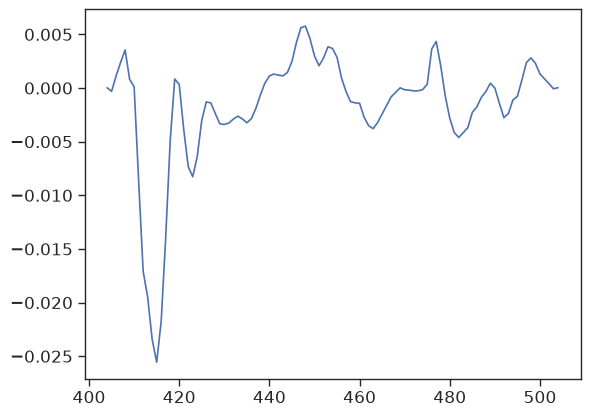

In [153]:
plt.figure()
plt.plot(speed_1.mean_ideal_minus_real)